In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv(
    '/content/IMDb Movies India.csv',
    encoding='latin1'
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 15509
Number of Columns: 10

Column Names:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
print("Missing Values in Each Column:")
print()

print(df.isnull().sum())

Missing Values in Each Column:

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [7]:
# Clean Year
df['Year'] = (
    df['Year']
    .astype(str)
    .str.extract(r'(\d{4})')[0]
)

df['Year'] = pd.to_numeric(
    df['Year'],
    errors='coerce'
)


# Clean Duration
df['Duration'] = (
    df['Duration']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df['Duration'] = pd.to_numeric(
    df['Duration'],
    errors='coerce'
)


# Clean Votes
df['Votes'] = (
    df['Votes']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)')[0]
)

df['Votes'] = pd.to_numeric(
    df['Votes'],
    errors='coerce'
)


# Clean Rating
df['Rating'] = pd.to_numeric(
    df['Rating'],
    errors='coerce'
)


print("Data cleaned successfully!")

df.head()

Data cleaned successfully!


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,2021.0,90.0,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,2019.0,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,2010.0,105.0,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [8]:
analysis_df = df.dropna(
    subset=['Year', 'Rating']
).copy()

analysis_df['Year'] = (
    analysis_df['Year'].astype(int)
)

print(
    "Total movies in original dataset:",
    len(df)
)

print(
    "Movies available for rating analysis:",
    len(analysis_df)
)

analysis_df.head()

Total movies in original dataset: 15509
Movies available for rating analysis: 7919


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [9]:
year_rating = (
    analysis_df
    .groupby('Year')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Number_of_Movies=('Name', 'count')
    )
    .reset_index()
)

# Use years with at least 5 rated movies
year_rating = year_rating[
    year_rating['Number_of_Movies'] >= 5
]

year_rating = year_rating.sort_values(
    'Average_Rating',
    ascending=False
)

print("Top 10 Years by Average Rating:")

display(year_rating.head(10))

Top 10 Years by Average Rating:


,Year,Average_Rating,Number_of_Movies
18,1948,7.073684,19
20,1950,7.061290,31
10,1940,6.954545,11
22,1952,6.848148,27
23,1953,6.820690,29
25,1955,6.794737,38
27,1957,6.763462,52
21,1951,6.712500,32
91,2021,6.625641,78
19,1949,6.619231,26


In [10]:
best_year = year_rating.iloc[0]

print("Best Rated Year:",
      int(best_year['Year']))

print("Average Rating:",
      round(best_year['Average_Rating'], 2))

print("Number of Movies:",
      int(best_year['Number_of_Movies']))

Best Rated Year: 1948
Average Rating: 7.07
Number of Movies: 19


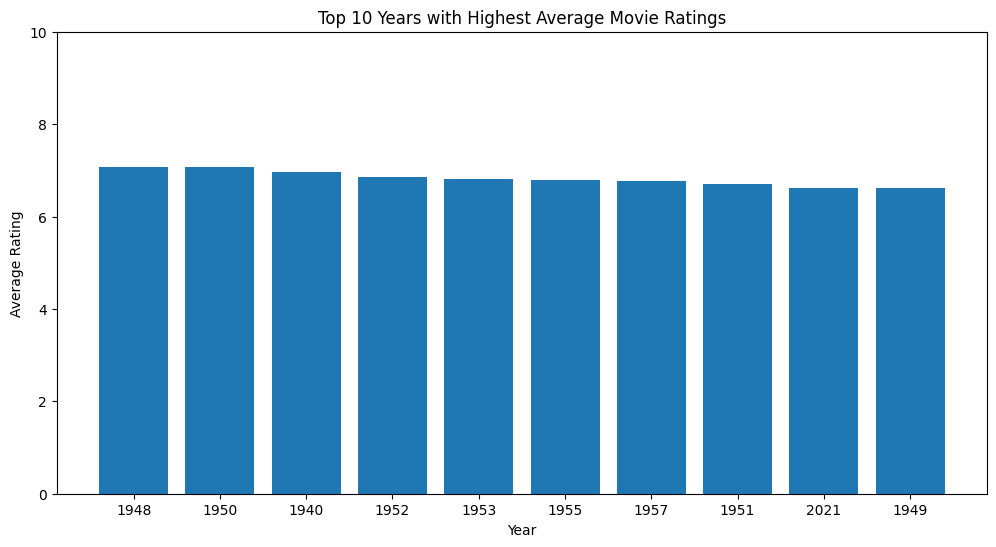

In [11]:
top_years = year_rating.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_years['Year'].astype(str),
    top_years['Average_Rating']
)

plt.title(
    'Top 10 Years with Highest Average Movie Ratings'
)

plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.ylim(0, 10)

plt.show()

In [12]:
duration_df = df.dropna(
    subset=['Duration', 'Rating']
).copy()

correlation = duration_df[
    'Duration'
].corr(duration_df['Rating'])

print(
    "Correlation between Duration and Rating:",
    round(correlation, 3)
)

Correlation between Duration and Rating: -0.031


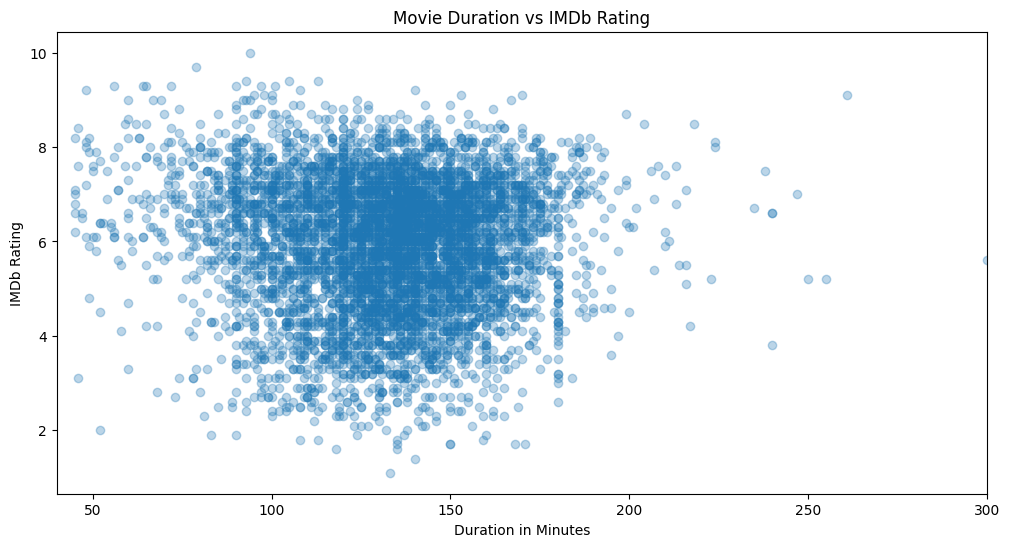

In [13]:
plt.figure(figsize=(12, 6))

plt.scatter(
    duration_df['Duration'],
    duration_df['Rating'],
    alpha=0.3
)

plt.title(
    'Movie Duration vs IMDb Rating'
)

plt.xlabel(
    'Duration in Minutes'
)

plt.ylabel(
    'IMDb Rating'
)

plt.xlim(40, 300)

plt.show()

In [14]:
top_10_movies = (
    analysis_df
    .sort_values(
        ['Rating'],
        ascending=False
    )
    [
        [
            'Name',
            'Year',
            'Rating',
            'Votes',
            'Director'
        ]
    ]
    .head(10)
)

print(
    "TOP 10 HIGHEST-RATED MOVIES"
)

display(top_10_movies)

TOP 10 HIGHEST-RATED MOVIES


,Name,Year,Rating,Votes,Director
8339,Love Qubool Hai,2020,10.0,5.0,Saif Ali Sayeed
5410,Half Songs,2021,9.7,7.0,Sriram Raja
2563,Breed,2020,9.6,48.0,Bobby Kumar
5077,Gho Gho Rani,2019,9.4,47.0,Munni Pankaj
14222,The Reluctant Crime,2020,9.4,16.0,Arvind Pratap
6852,June,2021,9.4,18.0,Suhrud Godbole
11704,Ram-Path,2017,9.4,5.0,Ashish Dubey
9105,Meher,2020,9.3,27.0,Rajat Bhardwaj
5125,God of gods,2019,9.3,46.0,Venkatesh Bk
11843,Refl3ct,2021,9.3,467.0,Nikhil Mahar


In [25]:
selected_year = 2020

top_movies_year = (
    analysis_df[
        analysis_df['Year'] == selected_year
    ]
    .sort_values(
        'Rating',
        ascending=False
    )
    [
        [
            'Name',
            'Rating',
            'Votes',
            'Director'
        ]
    ]
    .head(10)
)

print(
    f"Top 10 Movies of {selected_year}"
)

display(top_movies_year)

Top 10 Movies of 2020


,Name,Rating,Votes,Director
8339,Love Qubool Hai,10.0,5.0,Saif Ali Sayeed
2563,Breed,9.6,48.0,Bobby Kumar
14222,The Reluctant Crime,9.4,16.0,Arvind Pratap
9105,Meher,9.3,27.0,Rajat Bhardwaj
13431,Srinagar,9.1,28.0,Sanoj Mishra
13384,Soorarai Pottru,9.1,83029.0,Sudha Kongara
14060,The Evening Show,8.9,60.0,Parth Sharma
9189,Mera Ramrajya Nai Kranti,8.8,16.0,Shyam Bharteey
1432,Awasaan,8.7,21.0,Rajat Kumar Chaturvedi
12664,Secret Attack,8.6,21.0,Hemendra Kumar Singh


In [17]:
votes_df = df.dropna(
    subset=['Year', 'Votes']
).copy()

vote_threshold = (
    votes_df['Votes'].median()
)

popular_movies = votes_df[
    votes_df['Votes'] >= vote_threshold
]

popular_per_year = (
    popular_movies
    .groupby('Year')
    .size()
    .reset_index(
        name='Popular Movies'
    )
)

print(
    "Popularity threshold:",
    int(vote_threshold),
    "votes"
)

display(
    popular_per_year.tail(20)
)

Popularity threshold: 55 votes


,Year,Popular Movies
61,2002.0,77
62,2003.0,99
63,2004.0,100
64,2005.0,121
65,2006.0,87
66,2007.0,104
67,2008.0,109
68,2009.0,107
69,2010.0,119
70,2011.0,114


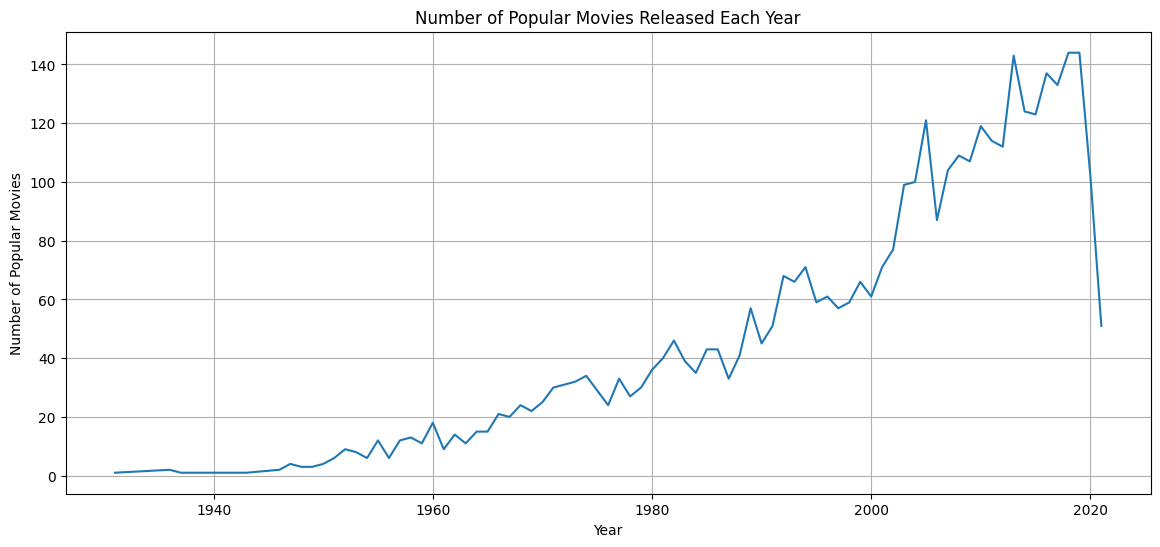

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    popular_per_year['Year'],
    popular_per_year['Popular Movies']
)

plt.title(
    'Number of Popular Movies Released Each Year'
)

plt.xlabel('Year')
plt.ylabel('Number of Popular Movies')

plt.grid()

plt.show()

In [19]:
votes_rating_df = df.dropna(
    subset=['Votes', 'Rating']
)

correlation = (
    votes_rating_df['Votes']
    .corr(votes_rating_df['Rating'])
)

print(
    "Votes vs Rating Correlation:",
    round(correlation, 3)
)

Votes vs Rating Correlation: 0.127


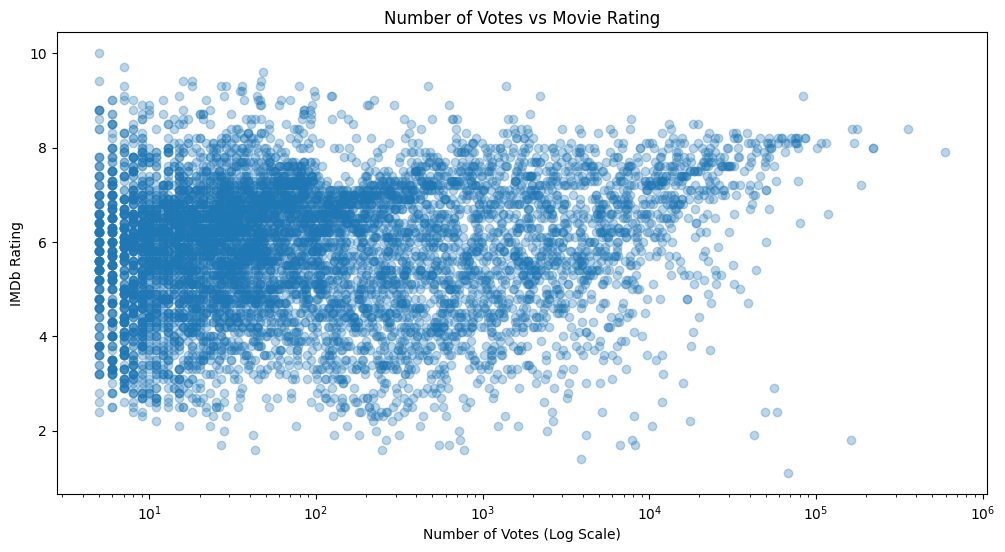

In [20]:
plt.figure(figsize=(12, 6))

plt.scatter(
    votes_rating_df['Votes'],
    votes_rating_df['Rating'],
    alpha=0.3
)

plt.xscale('log')

plt.title(
    'Number of Votes vs Movie Rating'
)

plt.xlabel(
    'Number of Votes (Log Scale)'
)

plt.ylabel(
    'IMDb Rating'
)

plt.show()

In [21]:
top_directors = (
    df['Director']
    .dropna()
    .value_counts()
    .head(10)
)

print(
    "Top 10 Directors with Most Movies"
)

display(
    top_directors.to_frame(
        'Number of Movies'
    )
)

Top 10 Directors with Most Movies


,Number of Movies
Director,
Jayant Desai,58
Kanti Shah,57
Babubhai Mistry,50
Mahesh Bhatt,48
Master Bhagwan,47
Nanabhai Bhatt,46
Dhirubhai Desai,46
Mohammed Hussain,44
David Dhawan,44


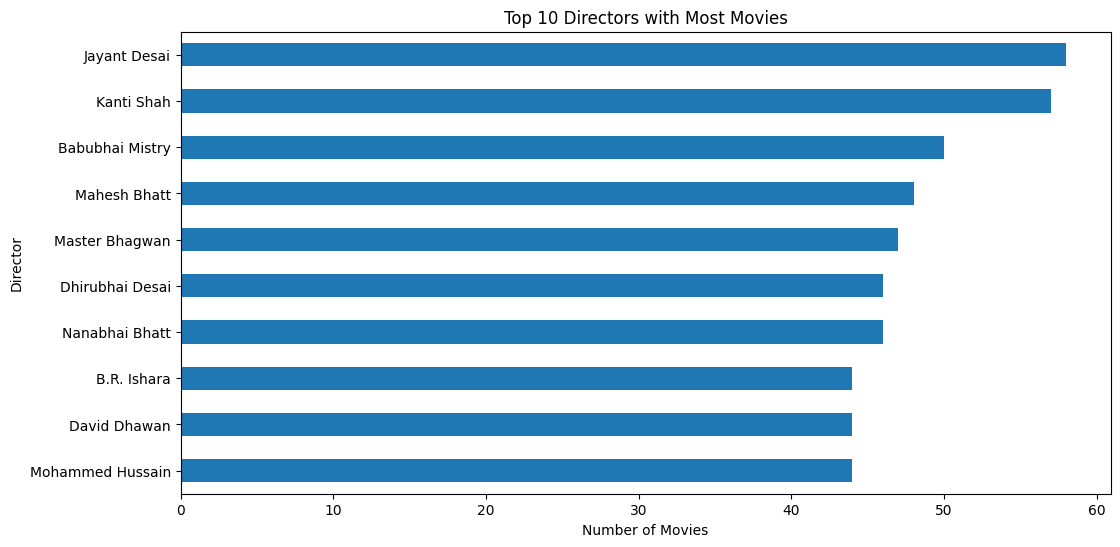

In [22]:
plt.figure(figsize=(12, 6))

top_directors.sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 10 Directors with Most Movies'
)

plt.xlabel(
    'Number of Movies'
)

plt.ylabel(
    'Director'
)

plt.show()

In [26]:
all_actors = pd.concat(
    [
        df['Actor 1'],
        df['Actor 2'],
        df['Actor 3']
    ]
).dropna()

top_actors = (
    all_actors
    .value_counts()
    .head(10)
)

print(
    "Top 10 Actors with Most Movie Appearances"
)

display(
    top_actors.to_frame(
        'Number of Movies'
    )
)

Top 10 Actors with Most Movie Appearances


,Number of Movies
Mithun Chakraborty,241
Dharmendra,231
Ashok Kumar,227
Jeetendra,179
Amitabh Bachchan,178
Rekha,142
Rajesh Khanna,139
Shashi Kapoor,133
Shatrughan Sinha,131
Shakti Kapoor,131


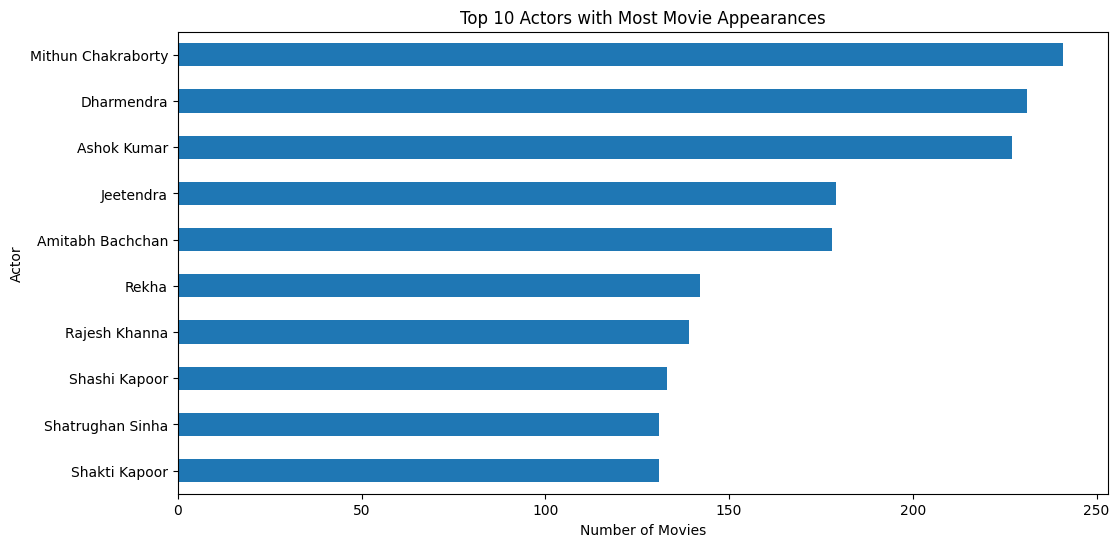

In [24]:
plt.figure(figsize=(12, 6))

top_actors.sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 10 Actors with Most Movie Appearances'
)

plt.xlabel(
    'Number of Movies'
)

plt.ylabel(
    'Actor'
)

plt.show()